In [1]:
import numpy as np
import matplotlib
# matplotlib.use('Agg')
import matplotlib.pyplot as plt

np.random.seed(44)

size_1, size_2 = 100, 50

xs = np.concatenate([np.random.randn(size_1) + 3, np.random.randn(size_2) + 5])
ys = np.concatenate([np.random.randn(size_1) - 4, np.random.randn(size_2)*2 - 8])
zs = np.concatenate([[0] * size_1, [1] * size_2])

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def predict(wx, wy, b):
    return sigmoid(wx * xs + wy * ys + b)

def cross_entropy(zs, zhats):
    return -np.sum(zs * np.log(zhats) + (1 - zs) * np.log(1 - zhats))

Analytic gradient descent:

$$
\theta = \begin{pmatrix}
w_x \\ w_y \\ b
\end{pmatrix}
$$

$$
\hat{z}(\theta) = \frac{1}{1 + e^{-(w_x x + w_y y + b)}}
$$

$$
L(\theta) = \sum [ z_i \log(\hat{z_i}) + (1 - z_i)\log(1 - \hat{z_i})]
$$

$$
\theta^* = \theta - \eta \nabla L(\theta)
$$

$$
\partial L / \partial w_x = (\hat{z} - z) \cdot x
$$

$$
\partial L / \partial w_y = (\hat{z} - z) \cdot y
$$

$$
\partial L / \partial b = (\hat{z} - z)
$$

In [32]:
from sympy import symbols, exp, log, Derivative, simplify

theta, w_x, w_y, b, L, z_hat, x, y, z = symbols(r'\theta w_x w_y b L, \hat{z} x y z')
sig = 1 / (1 + exp(-(w_x * x + w_y * y + b)))
L = z * log(sig) + (1 - z) * log ( 1 - sig)
simplify(Derivative(L, w_x, evaluate=True))

x*(z*exp(b + w_x*x + w_y*y) + z - exp(b + w_x*x + w_y*y))/(exp(b + w_x*x + w_y*y) + 1)

In [7]:
def grad_analytic(wx, wy, b):
    zhats = predict(wx, wy, b)
    error = zhats - zs
    dwx = np.sum(error * xs)
    dwy = np.sum(error * ys)
    db  = np.sum(error)
    return dwx, dwy, db

Iter 0: wx=-0.199 wy=-0.042 b=-0.250 CE=104.599 Acc=0.67
Iter 1000: wx=2.700 wy=-2.716 b=-26.166 CE=12.756 Acc=0.97
Iter 2000: wx=2.597 wy=-2.619 b=-25.233 CE=12.666 Acc=0.97
Iter 3000: wx=2.513 wy=-2.540 b=-24.472 CE=12.607 Acc=0.97
Iter 4000: wx=2.446 wy=-2.477 b=-23.867 CE=12.569 Acc=0.97

Final: Accuracy=0.97, CE=12.546
Parameters: wx=2.3940, wy=-2.4286, b=-23.3951


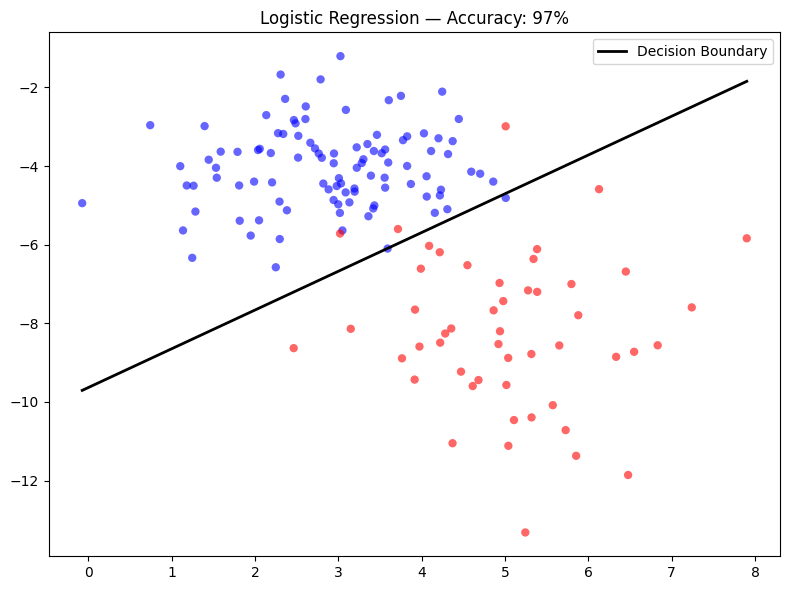

In [6]:
wx, wy, b = 0.0, 0.0, 0.0
lr = 0.01
for i in range(5000):
    gwx, gwy, gb = grad_analytic(wx, wy, b)
    wx -= lr * gwx
    wy -= lr * gwy
    b -= lr * gb
    if i % 1000 == 0:
        ce = cross_entropy(zs, predict(wx, wy, b))
        preds = (predict(wx, wy, b) >= 0.5).astype(int)
        acc = (preds == zs).mean()
        print(f'Iter {i}: wx={wx:.3f} wy={wy:.3f} b={b:.3f} CE={ce:.3f} Acc={acc:.2f}')

preds = (predict(wx, wy, b) >= 0.5).astype(int)
acc = (preds == zs).mean()
ce = cross_entropy(zs, predict(wx, wy, b))
print(f'\nFinal: Accuracy={acc:.2f}, CE={ce:.3f}')
print(f'Parameters: wx={wx:.4f}, wy={wy:.4f}, b={b:.4f}')

# Boundary: wx*x + wy*y + b = 0 => y = (-wx*x - b) / wy
x_line = np.linspace(xs.min(), xs.max(), 100)
y_line = (-wx * x_line - b) / wy

plt.figure(figsize=(8, 6))
plt.scatter(xs, ys, c=zs, cmap='bwr', alpha=0.6, edgecolors='none')
plt.plot(x_line, y_line, 'k-', linewidth=2, label='Decision Boundary')
plt.title(f'Logistic Regression — Accuracy: {acc:.0%}')
plt.legend()
plt.tight_layout()